# Geometry Working Memory

https://www.biorxiv.org/content/10.64898/2026.08.31.748237v1

In [1]:
# libraries

import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
import scipy
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import fdrcorrection
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


In [ ]:
### set paths and settings

path_root = '/path_to_local'

# settings

subjects = [f'sub_{i:02d}' for i in range(1, 50)]

time_windows = ['encode', 'maint', 's2']
pca_aligned_folder = 'pca_aligned'
surrogate_pca_aligned_folder = 'surrogate_pca_aligned'
conditions = ['update', 'inhibition']

k_start, k_end = 0, 2       # 0,2 means leading three PCs

### settings figures

yaxis_labels = 1
# if yaxis_labels = 1, labels in y-axis in encode panel
# if yaxis_labels = 2, labels in y-axis in encode and maintenance panels

xaxis_labels = True
# if True, labels in x-axis
# if False, no labels in x-axis

# CORRECT TRIALS

In [3]:
trial_type = 'correct_trials'

# Principal Angle (PA) - by load

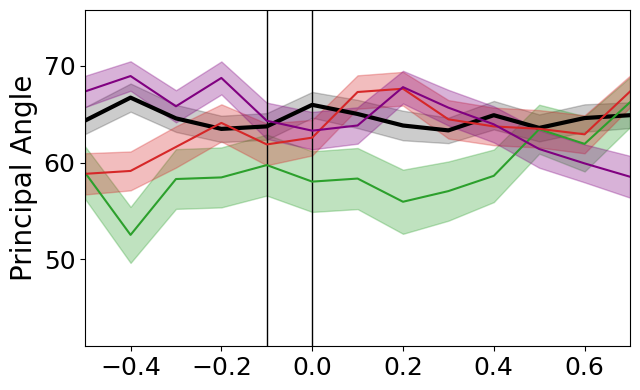

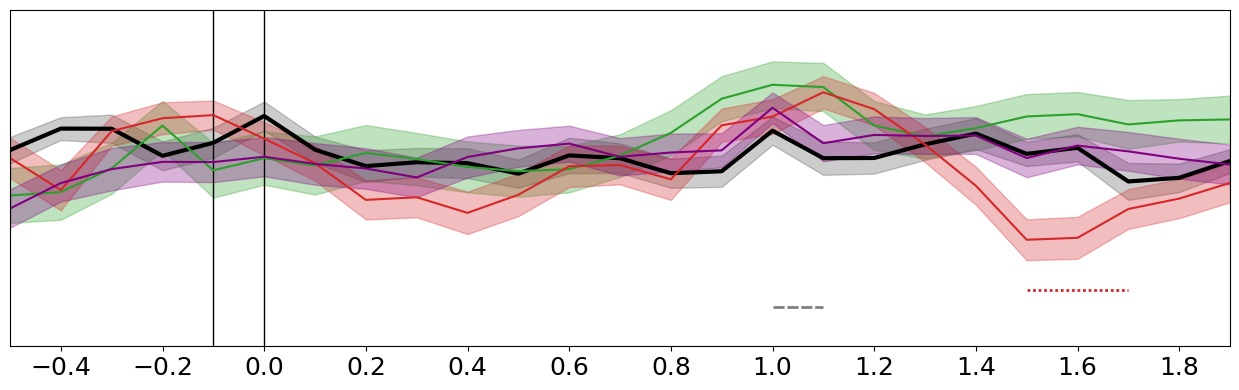

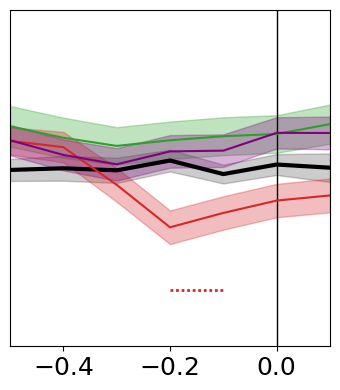

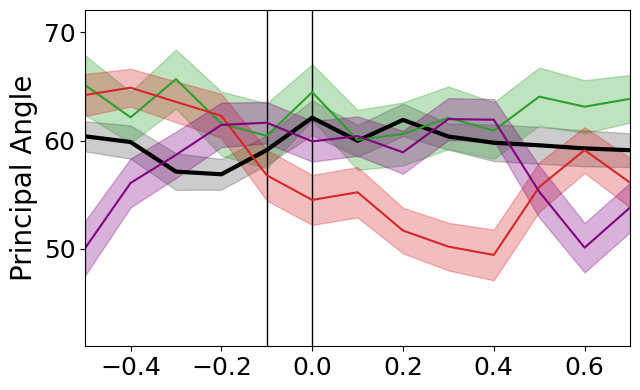

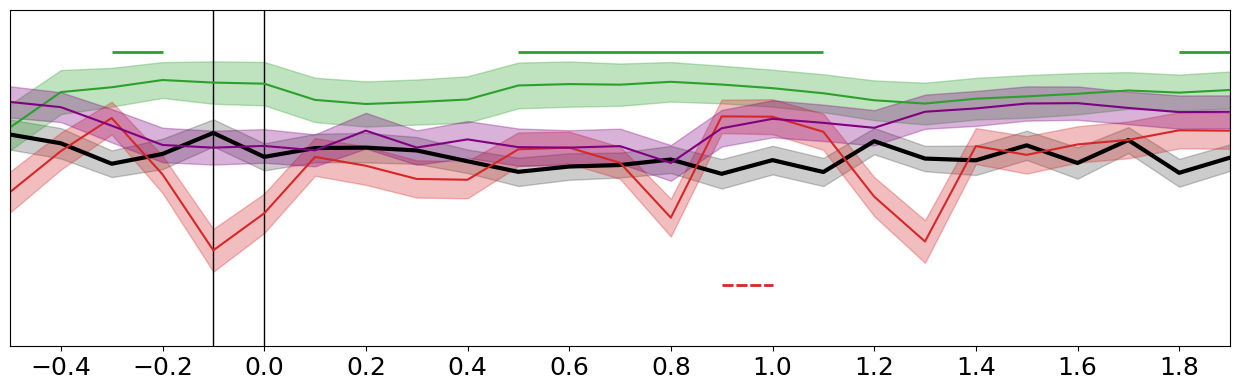

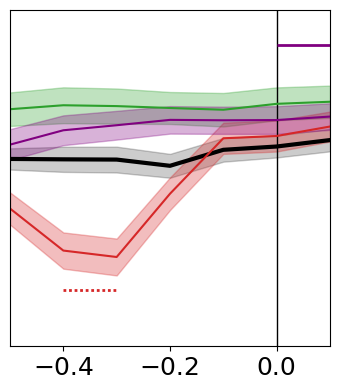

In [4]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'alignment_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_01_PA_pool_features_by_load')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

time_windows = ['encode', 'maint', 's2']

### apply FDR to all the concatenated p_values

p_values_uncorrected_list_inhibition_vs_surrogate = {}
p_values_uncorrected_list_update_vs_surrogate = {}
p_values_uncorrected_list_control_vs_surrogate = {}

p_values_uncorrected_list_cue_inhibition = {}
p_values_uncorrected_list_cue_update = {}
p_values_uncorrected_list_cue_control = {}

p_values_corrected_list_inhibition_vs_surrogate = {}
p_values_corrected_list_update_vs_surrogate = {}
p_values_corrected_list_control_vs_surrogate = {}

p_values_corrected_list_cue_inhibition = {}
p_values_corrected_list_cue_update = {}
p_values_corrected_list_cue_control = {}

t_values_list_inhibition = {}
t_values_list_update = {}
t_values_list_control = {}

t_values_list_cue_inhibition = {}
t_values_list_cue_update = {}
t_values_list_cue_control = {}

for load_i in [1, 2]:

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # -----------------------------------------
        # Run statistical tests - surrogate
        # -----------------------------------------

        ## inhibition vs surrogate
        p_values = []
        for t in range(data_inhibition.shape[1]):
            t_values, p = ttest_rel(data_inhibition[:, t], surrogate_inhibition[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)

        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_inhibition_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## update vs surrogate
        p_values = []
        for t in range(data_update.shape[1]):
            t_values, p = ttest_rel(data_update[:, t], surrogate_update[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_update_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## control vs surrogate
        p_values = []
        for t in range(data_control.shape[1]):
            t_values, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_control_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        # -----------------------------------
        # Run statistical tests - cue effect
        # -----------------------------------

        if time_window == 'encode':

            data_encode_avg_inhibition = data_inhibition.copy()
            data_encode_avg_update = data_update.copy()
            data_encode_avg_control = data_control.copy()

        if time_window == 'maint':

            data_encode_avg_inhibition = np.concatenate((data_encode_avg_inhibition, data_inhibition), axis=1)
            data_encode_avg_update = np.concatenate((data_encode_avg_update, data_update), axis=1)
            data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)

            data_encode_avg_inhibition = np.nanmean(data_encode_avg_inhibition[:,5:18], axis=1)
            data_encode_avg_update = np.nanmean(data_encode_avg_update[:,5:18], axis=1)
            data_encode_avg_control = np.nanmean(data_encode_avg_control[:,5:18], axis=1)

        if time_window != 'encode': # not used here

            ## inhibition

            p_values = []
            t_values = []
            for t in range(data_inhibition.shape[1]):
                t, p = ttest_rel(data_inhibition[:, t], data_encode_avg_inhibition)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_inhibition[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_inhibition[time_window + '_' + str(load_i)] = t_values

            ## update

            p_values = []
            t_values = []
            for t in range(data_update.shape[1]):
                t, p = ttest_rel(data_update[:, t], data_encode_avg_update)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_update[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_update[time_window + '_' + str(load_i)] = t_values

            ## control

            p_values = []
            t_values = []
            for t in range(data_control.shape[1]):
                t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_control[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_control[time_window + '_' + str(load_i)] = t_values


##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for load_i in [1, 2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    for time_window in time_windows:

        base_key = f"{time_window}_{load_i}"

        # inhibition
        vals = p_values_uncorrected_list_inhibition_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("inhibition", base_key, len(vals)))

        # update
        vals = p_values_uncorrected_list_update_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("update", base_key, len(vals)))

        # control
        vals = p_values_uncorrected_list_control_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("control", base_key, len(vals)))

    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_inhibition_vs_surrogate[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_update_vs_surrogate[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_control_vs_surrogate[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for load_i in [1, 2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    # vectorize uncorrected p_values
    for time_window in time_windows:

        if time_window != 'encode':

            base_key = f"{time_window}_{load_i}"

            # inhibition
            vals = p_values_uncorrected_list_cue_inhibition[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("inhibition", base_key, len(vals)))

            # update
            vals = p_values_uncorrected_list_cue_update[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("update", base_key, len(vals)))

            # control
            vals = p_values_uncorrected_list_cue_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))


    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_cue_inhibition[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_cue_update[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_cue_control[key] = corrected_vals







### plots

for load_i in [1, 2]:

    # find common y-axis limits

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']



        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

        # axis limits

        ymax_observed = max((mean_inhibition + std_inhibition).max(), (mean_update + std_update).max(), (mean_control + std_control).max())
        ymin_observed = min((mean_inhibition - std_inhibition).min(), (mean_update - std_update).min(), (mean_control - std_control).min())

        ymax_surrogate = max((mean_inhibition_surrogate + std_inhibition_surrogate).max(), (mean_update_surrogate + std_update_surrogate).max(), (mean_control_surrogate + std_control_surrogate).max())
        ymin_surrogate = min((mean_inhibition_surrogate - std_inhibition_surrogate).min(), (mean_update_surrogate - std_update_surrogate).min(), (mean_control_surrogate - std_control_surrogate).min())

        ymax = max((ymax_observed, ymax_surrogate))
        ymin = min((ymin_observed, ymin_surrogate))

        if time_window == 'encode':

            global_ymin = ymin
            global_ymax = ymax

        else:

            if ymax > global_ymax:
                global_ymax = ymax
            if ymin < global_ymin:
                global_ymin = ymin

    # now, pass the code to do the actual plots

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # ------------------------------------------
        # FDR corrected p-values - surrogate effect
        # ------------------------------------------

        ## inhibition vs update

        p_values_corrected_list = p_values_corrected_list_inhibition_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_inhibition_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## update vs update

        p_values_corrected_list = p_values_corrected_list_update_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_update_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## control vs update

        p_values_corrected_list = p_values_corrected_list_control_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_control_vs_surrogate = np.where(p_corrected < 0.025)[0]


        # ------------------------------------
        # FDR corrected p-values - cue effect
        # ------------------------------------

        if time_window != 'encode':

            ## inhibition 

            p_values_corrected_list = p_values_corrected_list_cue_inhibition.copy()
            t_values_list = t_values_list_cue_inhibition.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_inhibition_cue_positive = []
                significant_timepoints_inhibition_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_inhibition_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_inhibition_cue_negative.append(p_i)

                significant_timepoints_inhibition_cue_positive = np.array(significant_timepoints_inhibition_cue_positive)
                significant_timepoints_inhibition_cue_negative = np.array(significant_timepoints_inhibition_cue_negative)

            else:

                significant_timepoints_inhibition_cue_positive = np.array([])
                significant_timepoints_inhibition_cue_negative = np.array([])

            ## update 

            p_values_corrected_list = p_values_corrected_list_cue_update.copy()
            t_values_list = t_values_list_cue_update.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_update_cue_positive = []
                significant_timepoints_update_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_update_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_update_cue_negative.append(p_i)

                significant_timepoints_update_cue_positive = np.array(significant_timepoints_update_cue_positive)
                significant_timepoints_update_cue_negative = np.array(significant_timepoints_update_cue_negative)

            else:

                significant_timepoints_update_cue_positive = np.array([])
                significant_timepoints_update_cue_negative = np.array([])

            ## control 

            p_values_corrected_list = p_values_corrected_list_cue_control.copy()
            t_values_list = t_values_list_cue_control.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_control_cue_positive = []
                significant_timepoints_control_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_control_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_control_cue_negative.append(p_i)

                significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

            else:

                significant_timepoints_control_cue_positive = np.array([])
                significant_timepoints_control_cue_negative = np.array([])








        # ---------------------
        # Time axis
        # ---------------------
        time = (np.arange(data_inhibition.shape[1]) - index_of_zero) * 0.1  # sec

        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])













        # ---------------------
        # Plot
        # ---------------------

        plt.figure(figsize=(len(segments)/2, 4))

        if time_window == 'encode':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 'maint':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 's2':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

        if time_window == 'encode':
            plt.xlim(-0.500, 0.700)
        elif time_window == 'maint':
            plt.xlim(-0.500, 1.900)
        elif time_window == 's2':
            plt.xlim(-0.500, 0.100)

        ## surrogate

        # control condition
        plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
        plt.fill_between(time, mean_control_surrogate - std_control_surrogate, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

        ## observed

        # control condition
        plt.plot(time, mean_control, label='Control', color='tab:green')
        plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.3, color='tab:green')

        # inhibition
        plt.plot(time, mean_inhibition, label='Relevant', color='tab:red')
        plt.fill_between(time, mean_inhibition - std_inhibition, mean_inhibition + std_inhibition, alpha=0.3, color='tab:red')

        # update
        plt.plot(time, mean_update, label='Nonrelevant', color='purple')
        plt.fill_between(time, mean_update - std_update, mean_update + std_update, alpha=0.3, color='purple')



        # y-axis limits
        padding = 0.1 * (global_ymax - global_ymin)
        global_ymin -= padding
        global_ymax += padding
        plt.ylim(global_ymin, global_ymax)




        ### Stats - surrogate effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        # inhibition vs surrogate

        if significant_timepoints_inhibition_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_inhibition_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

        # update vs surrogate

        if significant_timepoints_update_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.25)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_update_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2)

        # control vs surrogate

        if significant_timepoints_control_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.5)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_control_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:green', linewidth=2)







        ### Stats - cue effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        if time_window != 'encode':

            # inhibition - positive

            if significant_timepoints_inhibition_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # inhibition - negative

            if significant_timepoints_inhibition_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  

            # update - positive

            if significant_timepoints_update_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.8)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # update - negative

            if significant_timepoints_update_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.6)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (1, 1)))  

            # control - positive

            if significant_timepoints_control_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.4)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # control - negative

            if significant_timepoints_control_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (1, 1)))  










        # Labels and legend
        if yaxis_labels == 1:
            if time_window == 'encode':
                plt.ylabel('Principal Angle', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(10))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1d'))

                # Remove the 40 tick
                ax.set_ylim(bottom=41)  # or 45, depending on taste

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])
        elif yaxis_labels == 2:
            if time_window == 'encode' or time_window == 'maint':
                plt.ylabel('Principal Angle', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(10))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1d'))

                # Remove the 40 tick
                ax.set_ylim(bottom=41)  # or 45, depending on taste

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])


        if xaxis_labels == False:
            plt.xticks([])
        else:
            if time_window == 'encode':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
            elif time_window == 'maint':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
            elif time_window == 's2':
                plt.xticks([-0.4, -0.2, 0], fontsize=18)

        plt.tight_layout()

        # Save figure before showing it
        output_filename = os.path.join(path_figures, 'figure_load' + str(load_i) + '_' + time_window + '.png')
        plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
        
        plt.show()



# Variance Accounted For (VAF) - by load

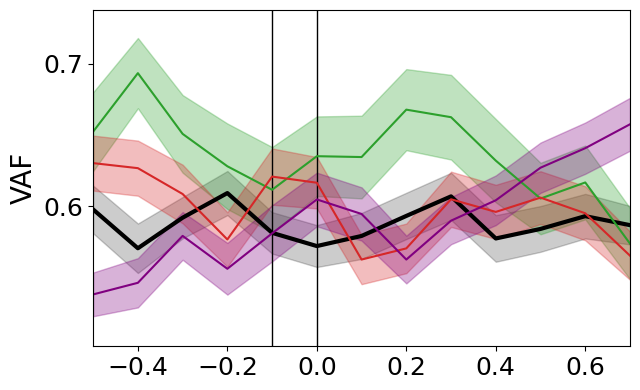

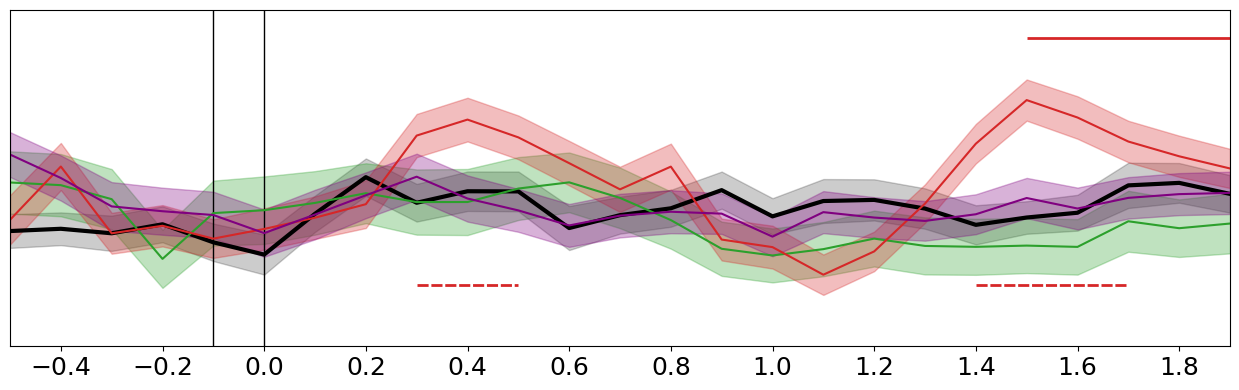

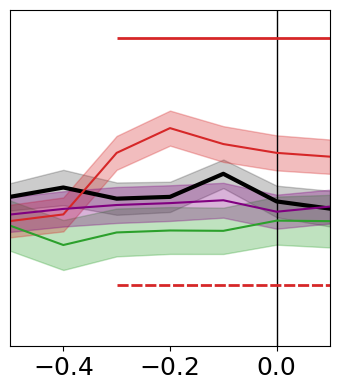

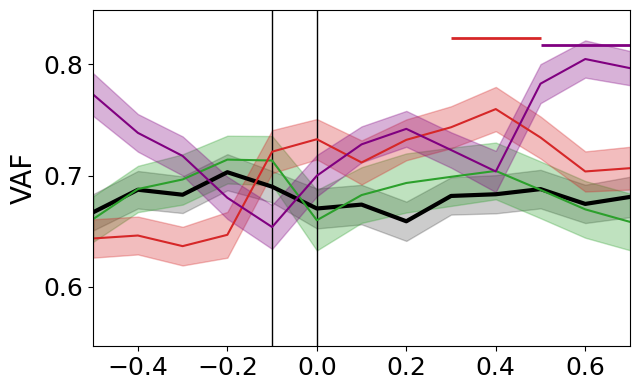

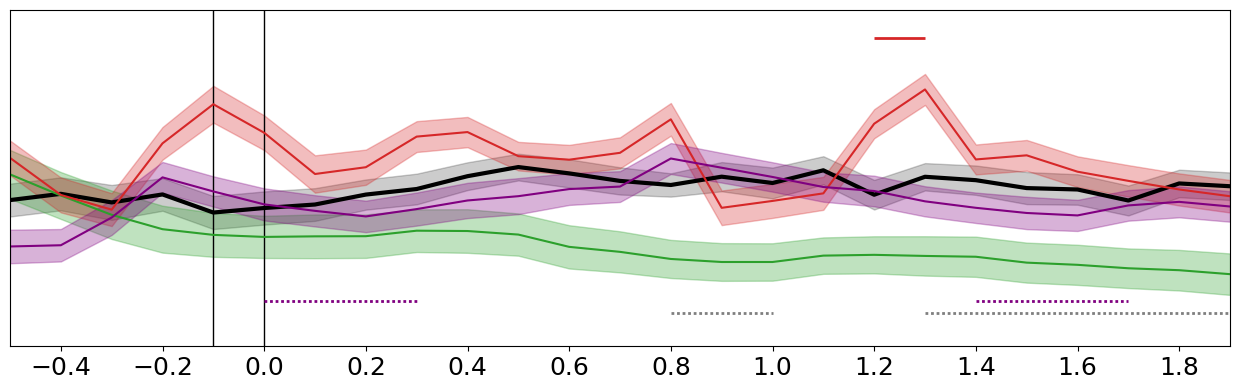

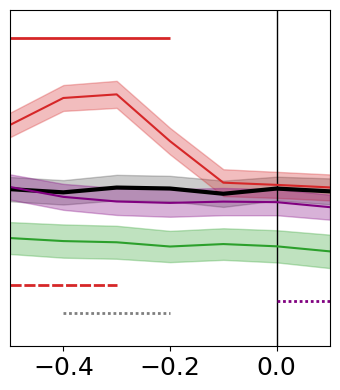

In [5]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'alignment_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_02_VAF_pool_features_by_load')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

time_windows = ['encode', 'maint', 's2']

### apply FDR to all the concatenated p_values

p_values_uncorrected_list_inhibition_vs_surrogate = {}
p_values_uncorrected_list_update_vs_surrogate = {}
p_values_uncorrected_list_control_vs_surrogate = {}

p_values_uncorrected_list_cue_inhibition = {}
p_values_uncorrected_list_cue_update = {}
p_values_uncorrected_list_cue_control = {}

p_values_corrected_list_inhibition_vs_surrogate = {}
p_values_corrected_list_update_vs_surrogate = {}
p_values_corrected_list_control_vs_surrogate = {}

p_values_corrected_list_cue_inhibition = {}
p_values_corrected_list_cue_update = {}
p_values_corrected_list_cue_control = {}

t_values_list_inhibition = {}
t_values_list_update = {}
t_values_list_control = {}

t_values_list_cue_inhibition = {}
t_values_list_cue_update = {}
t_values_list_cue_control = {}

for load_i in [1, 2]:

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # -----------------------------------------
        # Run statistical tests - surrogate
        # -----------------------------------------

        ## inhibition vs surrogate
        p_values = []
        for t in range(data_inhibition.shape[1]):
            t_values, p = ttest_rel(data_inhibition[:, t], surrogate_inhibition[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)

        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_inhibition_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## update vs surrogate
        p_values = []
        for t in range(data_update.shape[1]):
            t_values, p = ttest_rel(data_update[:, t], surrogate_update[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_update_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## control vs surrogate
        p_values = []
        for t in range(data_control.shape[1]):
            t_values, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_control_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        # -----------------------------------
        # Run statistical tests - cue effect
        # -----------------------------------

        if time_window == 'encode':

            data_encode_avg_inhibition = data_inhibition.copy()
            data_encode_avg_update = data_update.copy()
            data_encode_avg_control = data_control.copy()

        if time_window == 'maint':

            data_encode_avg_inhibition = np.concatenate((data_encode_avg_inhibition, data_inhibition), axis=1)
            data_encode_avg_update = np.concatenate((data_encode_avg_update, data_update), axis=1)
            data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)

            data_encode_avg_inhibition = np.nanmean(data_encode_avg_inhibition[:,5:18], axis=1)
            data_encode_avg_update = np.nanmean(data_encode_avg_update[:,5:18], axis=1)
            data_encode_avg_control = np.nanmean(data_encode_avg_control[:,5:18], axis=1)

        if time_window != 'encode': # not used here

            ## inhibition

            p_values = []
            t_values = []
            for t in range(data_inhibition.shape[1]):
                t, p = ttest_rel(data_inhibition[:, t], data_encode_avg_inhibition)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_inhibition[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_inhibition[time_window + '_' + str(load_i)] = t_values

            ## update

            p_values = []
            t_values = []
            for t in range(data_update.shape[1]):
                t, p = ttest_rel(data_update[:, t], data_encode_avg_update)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_update[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_update[time_window + '_' + str(load_i)] = t_values

            ## control

            p_values = []
            t_values = []
            for t in range(data_control.shape[1]):
                t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_control[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_control[time_window + '_' + str(load_i)] = t_values


##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for load_i in [1, 2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    for time_window in time_windows:

        base_key = f"{time_window}_{load_i}"

        # inhibition
        vals = p_values_uncorrected_list_inhibition_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("inhibition", base_key, len(vals)))

        # update
        vals = p_values_uncorrected_list_update_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("update", base_key, len(vals)))

        # control
        vals = p_values_uncorrected_list_control_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("control", base_key, len(vals)))

    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_inhibition_vs_surrogate[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_update_vs_surrogate[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_control_vs_surrogate[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for load_i in [1, 2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    # vectorize uncorrected p_values
    for time_window in time_windows:

        if time_window != 'encode':

            base_key = f"{time_window}_{load_i}"

            # inhibition
            vals = p_values_uncorrected_list_cue_inhibition[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("inhibition", base_key, len(vals)))

            # update
            vals = p_values_uncorrected_list_cue_update[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("update", base_key, len(vals)))

            # control
            vals = p_values_uncorrected_list_cue_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))


    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_cue_inhibition[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_cue_update[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_cue_control[key] = corrected_vals







### plots

for load_i in [1, 2]:

    # find common y-axis limits

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']


        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

        # axis limits

        ymax_observed = max((mean_inhibition + std_inhibition).max(), (mean_update + std_update).max(), (mean_control + std_control).max())
        ymin_observed = min((mean_inhibition - std_inhibition).min(), (mean_update - std_update).min(), (mean_control - std_control).min())

        ymax_surrogate = max((mean_inhibition_surrogate + std_inhibition_surrogate).max(), (mean_update_surrogate + std_update_surrogate).max(), (mean_control_surrogate + std_control_surrogate).max())
        ymin_surrogate = min((mean_inhibition_surrogate - std_inhibition_surrogate).min(), (mean_update_surrogate - std_update_surrogate).min(), (mean_control_surrogate - std_control_surrogate).min())

        ymax = max((ymax_observed, ymax_surrogate))
        ymin = min((ymin_observed, ymin_surrogate))

        if time_window == 'encode':

            global_ymin = ymin
            global_ymax = ymax

        else:

            if ymax > global_ymax:
                global_ymax = ymax
            if ymin < global_ymin:
                global_ymin = ymin

    # now, pass the code to do the actual plots

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)


        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # ------------------------------------------
        # FDR corrected p-values - surrogate effect
        # ------------------------------------------

        ## inhibition vs update

        p_values_corrected_list = p_values_corrected_list_inhibition_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_inhibition_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## update vs update

        p_values_corrected_list = p_values_corrected_list_update_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_update_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## control vs update

        p_values_corrected_list = p_values_corrected_list_control_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_control_vs_surrogate = np.where(p_corrected < 0.025)[0]


        # ------------------------------------
        # FDR corrected p-values - cue effect
        # ------------------------------------

        if time_window != 'encode':

            ## inhibition 

            p_values_corrected_list = p_values_corrected_list_cue_inhibition.copy()
            t_values_list = t_values_list_cue_inhibition.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_inhibition_cue_positive = []
                significant_timepoints_inhibition_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_inhibition_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_inhibition_cue_negative.append(p_i)

                significant_timepoints_inhibition_cue_positive = np.array(significant_timepoints_inhibition_cue_positive)
                significant_timepoints_inhibition_cue_negative = np.array(significant_timepoints_inhibition_cue_negative)

            else:

                significant_timepoints_inhibition_cue_positive = np.array([])
                significant_timepoints_inhibition_cue_negative = np.array([])

            ## update 

            p_values_corrected_list = p_values_corrected_list_cue_update.copy()
            t_values_list = t_values_list_cue_update.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_update_cue_positive = []
                significant_timepoints_update_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_update_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_update_cue_negative.append(p_i)

                significant_timepoints_update_cue_positive = np.array(significant_timepoints_update_cue_positive)
                significant_timepoints_update_cue_negative = np.array(significant_timepoints_update_cue_negative)

            else:

                significant_timepoints_update_cue_positive = np.array([])
                significant_timepoints_update_cue_negative = np.array([])

            ## control 

            p_values_corrected_list = p_values_corrected_list_cue_control.copy()
            t_values_list = t_values_list_cue_control.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_control_cue_positive = []
                significant_timepoints_control_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_control_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_control_cue_negative.append(p_i)

                significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

            else:

                significant_timepoints_control_cue_positive = np.array([])
                significant_timepoints_control_cue_negative = np.array([])








        # ---------------------
        # Time axis
        # ---------------------
        time = (np.arange(data_inhibition.shape[1]) - index_of_zero) * 0.1  # sec

        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])













        # ---------------------
        # Plot
        # ---------------------

        plt.figure(figsize=(len(segments)/2, 4))

        if time_window == 'encode':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 'maint':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 's2':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

        if time_window == 'encode':
            plt.xlim(-0.500, 0.700)
        elif time_window == 'maint':
            plt.xlim(-0.500, 1.900)
        elif time_window == 's2':
            plt.xlim(-0.500, 0.100)

        ## surrogate

        # control condition
        plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
        plt.fill_between(time, mean_control_surrogate - std_control_surrogate, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

        ## observed

        # control condition
        plt.plot(time, mean_control, label='Control', color='tab:green')
        plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.3, color='tab:green')

        # inhibition
        plt.plot(time, mean_inhibition, label='Relevant', color='tab:red')
        plt.fill_between(time, mean_inhibition - std_inhibition, mean_inhibition + std_inhibition, alpha=0.3, color='tab:red')

        # update
        plt.plot(time, mean_update, label='Nonrelevant', color='purple')
        plt.fill_between(time, mean_update - std_update, mean_update + std_update, alpha=0.3, color='purple')



        # y-axis limits
        padding = 0.1 * (global_ymax - global_ymin)
        global_ymin -= padding
        global_ymax += padding
        plt.ylim(global_ymin, global_ymax)




        ### Stats - surrogate effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        # inhibition vs surrogate

        if significant_timepoints_inhibition_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_inhibition_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

        # update vs surrogate

        if significant_timepoints_update_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.25)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_update_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2)

        # control vs surrogate

        if significant_timepoints_control_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.5)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_control_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:green', linewidth=2)







        ### Stats - cue effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        if time_window != 'encode':

            # inhibition - positive

            if significant_timepoints_inhibition_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # inhibition - negative

            if significant_timepoints_inhibition_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  

            # update - positive

            if significant_timepoints_update_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.8)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # update - negative

            if significant_timepoints_update_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.6)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (1, 1)))  

            # control - positive

            if significant_timepoints_control_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.4)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # control - negative

            if significant_timepoints_control_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (1, 1)))  







        # Labels and legend
        if yaxis_labels == 1:
            if time_window == 'encode':
                plt.ylabel('VAF', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(0.1))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])
        elif yaxis_labels == 2:
            if time_window == 'encode' or time_window == 'maint':
                plt.ylabel('VAF', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(0.1))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])


        if xaxis_labels == False:
            plt.xticks([])
        else:
            if time_window == 'encode':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
            elif time_window == 'maint':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
            elif time_window == 's2':
                plt.xticks([-0.4, -0.2, 0], fontsize=18)

        plt.tight_layout()

        # Save figure before showing it
        output_filename = os.path.join(path_figures, 'figure_load' + str(load_i) + '_' + time_window + '.png')
        plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
        
        plt.show()



# INCORRECT TRIALS

In [6]:
trial_type = 'incorrect_trials'

# Principal Angle (PA) - load 2

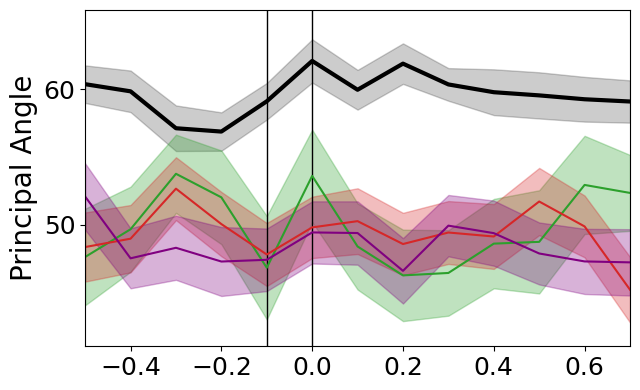

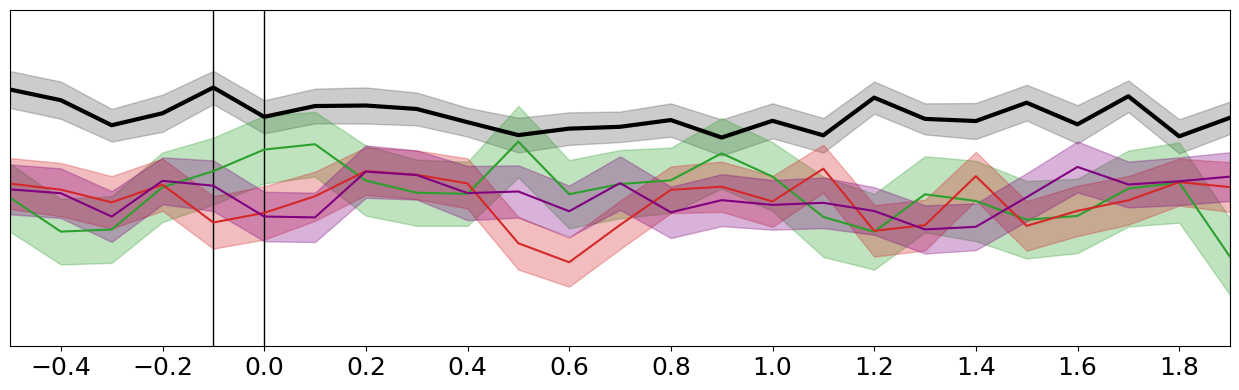

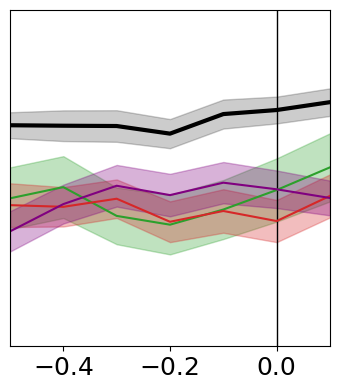

In [7]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'alignment_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_01_PA_pool_features_load2')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

time_windows = ['encode', 'maint', 's2']

### apply FDR to all the concatenated p_values

p_values_uncorrected_list_inhibition_vs_surrogate = {}
p_values_uncorrected_list_update_vs_surrogate = {}
p_values_uncorrected_list_control_vs_surrogate = {}

p_values_uncorrected_list_cue_inhibition = {}
p_values_uncorrected_list_cue_update = {}
p_values_uncorrected_list_cue_control = {}

p_values_corrected_list_inhibition_vs_surrogate = {}
p_values_corrected_list_update_vs_surrogate = {}
p_values_corrected_list_control_vs_surrogate = {}

p_values_corrected_list_cue_inhibition = {}
p_values_corrected_list_cue_update = {}
p_values_corrected_list_cue_control = {}

t_values_list_inhibition = {}
t_values_list_update = {}
t_values_list_control = {}

t_values_list_cue_inhibition = {}
t_values_list_cue_update = {}
t_values_list_cue_control = {}

for load_i in [2]:

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # -----------------------------------------
        # Run statistical tests - surrogate
        # -----------------------------------------

        ## inhibition vs surrogate
        p_values = []
        for t in range(data_inhibition.shape[1]):
            t_values, p = ttest_rel(data_inhibition[:, t], surrogate_inhibition[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)

        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_inhibition_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## update vs surrogate
        p_values = []
        for t in range(data_update.shape[1]):
            t_values, p = ttest_rel(data_update[:, t], surrogate_update[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_update_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## control vs surrogate
        p_values = []
        for t in range(data_control.shape[1]):
            t_values, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_control_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        # -----------------------------------
        # Run statistical tests - cue effect
        # -----------------------------------

        if time_window == 'encode':

            data_encode_avg_inhibition = data_inhibition.copy()
            data_encode_avg_update = data_update.copy()
            data_encode_avg_control = data_control.copy()

        if time_window == 'maint':

            data_encode_avg_inhibition = np.concatenate((data_encode_avg_inhibition, data_inhibition), axis=1)
            data_encode_avg_update = np.concatenate((data_encode_avg_update, data_update), axis=1)
            data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)

            data_encode_avg_inhibition = np.nanmean(data_encode_avg_inhibition[:,5:18], axis=1)
            data_encode_avg_update = np.nanmean(data_encode_avg_update[:,5:18], axis=1)
            data_encode_avg_control = np.nanmean(data_encode_avg_control[:,5:18], axis=1)

        if time_window != 'encode': # not used here

            ## inhibition

            p_values = []
            t_values = []
            for t in range(data_inhibition.shape[1]):
                t, p = ttest_rel(data_inhibition[:, t], data_encode_avg_inhibition)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_inhibition[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_inhibition[time_window + '_' + str(load_i)] = t_values

            ## update

            p_values = []
            t_values = []
            for t in range(data_update.shape[1]):
                t, p = ttest_rel(data_update[:, t], data_encode_avg_update)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_update[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_update[time_window + '_' + str(load_i)] = t_values

            ## control

            p_values = []
            t_values = []
            for t in range(data_control.shape[1]):
                t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_control[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_control[time_window + '_' + str(load_i)] = t_values


##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for load_i in [2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    for time_window in time_windows:

        base_key = f"{time_window}_{load_i}"

        # inhibition
        vals = p_values_uncorrected_list_inhibition_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("inhibition", base_key, len(vals)))

        # update
        vals = p_values_uncorrected_list_update_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("update", base_key, len(vals)))

        # control
        vals = p_values_uncorrected_list_control_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("control", base_key, len(vals)))

    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_inhibition_vs_surrogate[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_update_vs_surrogate[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_control_vs_surrogate[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for load_i in [2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    # vectorize uncorrected p_values
    for time_window in time_windows:

        if time_window != 'encode':

            base_key = f"{time_window}_{load_i}"

            # inhibition
            vals = p_values_uncorrected_list_cue_inhibition[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("inhibition", base_key, len(vals)))

            # update
            vals = p_values_uncorrected_list_cue_update[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("update", base_key, len(vals)))

            # control
            vals = p_values_uncorrected_list_cue_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))


    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_cue_inhibition[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_cue_update[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_cue_control[key] = corrected_vals







### plots

for load_i in [2]:

    # find common y-axis limits

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']



        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

        # axis limits

        ymax_observed = max((mean_inhibition + std_inhibition).max(), (mean_update + std_update).max(), (mean_control + std_control).max())
        ymin_observed = min((mean_inhibition - std_inhibition).min(), (mean_update - std_update).min(), (mean_control - std_control).min())

        ymax_surrogate = max((mean_inhibition_surrogate + std_inhibition_surrogate).max(), (mean_update_surrogate + std_update_surrogate).max(), (mean_control_surrogate + std_control_surrogate).max())
        ymin_surrogate = min((mean_inhibition_surrogate - std_inhibition_surrogate).min(), (mean_update_surrogate - std_update_surrogate).min(), (mean_control_surrogate - std_control_surrogate).min())

        ymax = max((ymax_observed, ymax_surrogate))
        ymin = min((ymin_observed, ymin_surrogate))

        if time_window == 'encode':

            global_ymin = ymin
            global_ymax = ymax

        else:

            if ymax > global_ymax:
                global_ymax = ymax
            if ymin < global_ymin:
                global_ymin = ymin

    # now, pass the code to do the actual plots

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'pa_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = pa_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = pa_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'pa_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            pa_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = pa_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # ------------------------------------------
        # FDR corrected p-values - surrogate effect
        # ------------------------------------------

        ## inhibition vs update

        p_values_corrected_list = p_values_corrected_list_inhibition_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_inhibition_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## update vs update

        p_values_corrected_list = p_values_corrected_list_update_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_update_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## control vs update

        p_values_corrected_list = p_values_corrected_list_control_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_control_vs_surrogate = np.where(p_corrected < 0.025)[0]


        # ------------------------------------
        # FDR corrected p-values - cue effect
        # ------------------------------------

        if time_window != 'encode':

            ## inhibition 

            p_values_corrected_list = p_values_corrected_list_cue_inhibition.copy()
            t_values_list = t_values_list_cue_inhibition.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_inhibition_cue_positive = []
                significant_timepoints_inhibition_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_inhibition_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_inhibition_cue_negative.append(p_i)

                significant_timepoints_inhibition_cue_positive = np.array(significant_timepoints_inhibition_cue_positive)
                significant_timepoints_inhibition_cue_negative = np.array(significant_timepoints_inhibition_cue_negative)

            else:

                significant_timepoints_inhibition_cue_positive = np.array([])
                significant_timepoints_inhibition_cue_negative = np.array([])

            ## update 

            p_values_corrected_list = p_values_corrected_list_cue_update.copy()
            t_values_list = t_values_list_cue_update.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_update_cue_positive = []
                significant_timepoints_update_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_update_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_update_cue_negative.append(p_i)

                significant_timepoints_update_cue_positive = np.array(significant_timepoints_update_cue_positive)
                significant_timepoints_update_cue_negative = np.array(significant_timepoints_update_cue_negative)

            else:

                significant_timepoints_update_cue_positive = np.array([])
                significant_timepoints_update_cue_negative = np.array([])

            ## control 

            p_values_corrected_list = p_values_corrected_list_cue_control.copy()
            t_values_list = t_values_list_cue_control.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_control_cue_positive = []
                significant_timepoints_control_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_control_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_control_cue_negative.append(p_i)

                significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

            else:

                significant_timepoints_control_cue_positive = np.array([])
                significant_timepoints_control_cue_negative = np.array([])








        # ---------------------
        # Time axis
        # ---------------------
        time = (np.arange(data_inhibition.shape[1]) - index_of_zero) * 0.1  # sec

        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])













        # ---------------------
        # Plot
        # ---------------------

        plt.figure(figsize=(len(segments)/2, 4))

        if time_window == 'encode':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 'maint':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 's2':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

        if time_window == 'encode':
            plt.xlim(-0.500, 0.700)
        elif time_window == 'maint':
            plt.xlim(-0.500, 1.900)
        elif time_window == 's2':
            plt.xlim(-0.500, 0.100)

        ## surrogate

        # control condition
        plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
        plt.fill_between(time, mean_control_surrogate - std_control_surrogate, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

        ## observed

        # control condition
        plt.plot(time, mean_control, label='Control', color='tab:green')
        plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.3, color='tab:green')

        # inhibition
        plt.plot(time, mean_inhibition, label='Relevant', color='tab:red')
        plt.fill_between(time, mean_inhibition - std_inhibition, mean_inhibition + std_inhibition, alpha=0.3, color='tab:red')

        # update
        plt.plot(time, mean_update, label='Nonrelevant', color='purple')
        plt.fill_between(time, mean_update - std_update, mean_update + std_update, alpha=0.3, color='purple')



        # y-axis limits
        padding = 0.1 * (global_ymax - global_ymin)
        global_ymin -= padding
        global_ymax += padding
        plt.ylim(global_ymin, global_ymax)




        ### Stats - surrogate effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        # inhibition vs surrogate

        if significant_timepoints_inhibition_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_inhibition_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

        # update vs surrogate

        if significant_timepoints_update_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.25)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_update_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2)

        # control vs surrogate

        if significant_timepoints_control_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.5)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_control_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:green', linewidth=2)







        ### Stats - cue effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        if time_window != 'encode':

            # inhibition - positive

            if significant_timepoints_inhibition_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # inhibition - negative

            if significant_timepoints_inhibition_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  

            # update - positive

            if significant_timepoints_update_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.8)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # update - negative

            if significant_timepoints_update_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.6)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (1, 1)))  

            # control - positive

            if significant_timepoints_control_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.4)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # control - negative

            if significant_timepoints_control_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (1, 1)))  










        # Labels and legend
        if yaxis_labels == 1:
            if time_window == 'encode':
                plt.ylabel('Principal Angle', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(10))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1d'))

                # Remove the 40 tick
                ax.set_ylim(bottom=41)  # or 45, depending on taste

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])
        elif yaxis_labels == 2:
            if time_window == 'encode' or time_window == 'maint':
                plt.ylabel('Principal Angle', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(10))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1d'))

                # Remove the 40 tick
                ax.set_ylim(bottom=41)  # or 45, depending on taste

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])


        if xaxis_labels == False:
            plt.xticks([])
        else:
            if time_window == 'encode':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
            elif time_window == 'maint':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
            elif time_window == 's2':
                plt.xticks([-0.4, -0.2, 0], fontsize=18)

        plt.tight_layout()

        # Save figure before showing it
        output_filename = os.path.join(path_figures, 'figure_load' + str(load_i) + '_' + time_window + '.png')
        plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
        
        plt.show()



# Variance Accounted For (VAF) - load 2

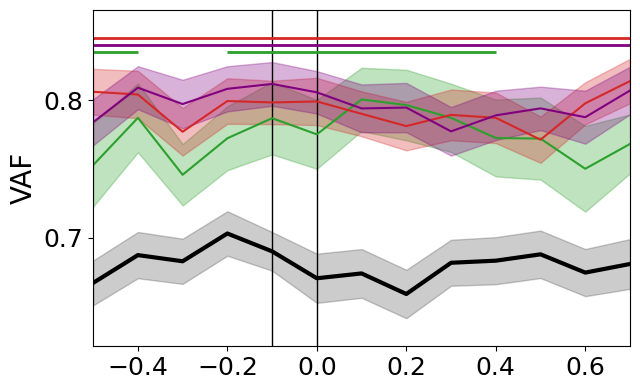

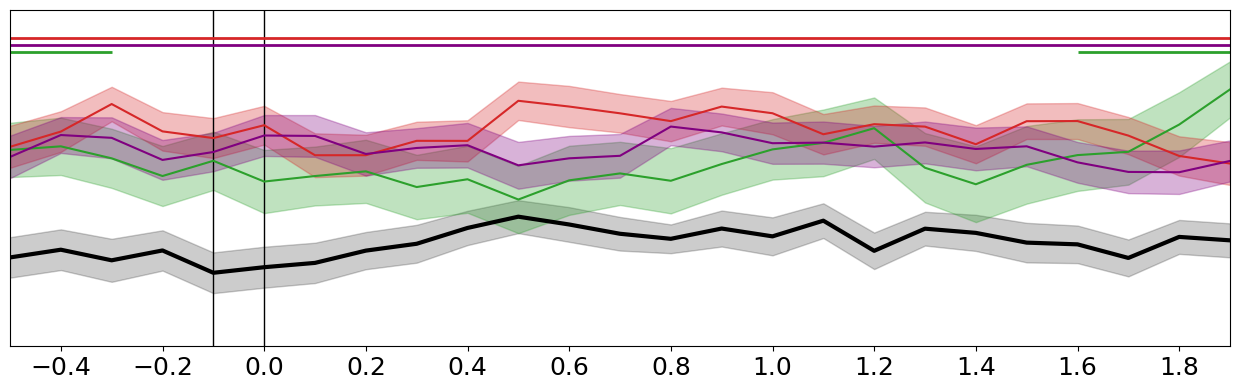

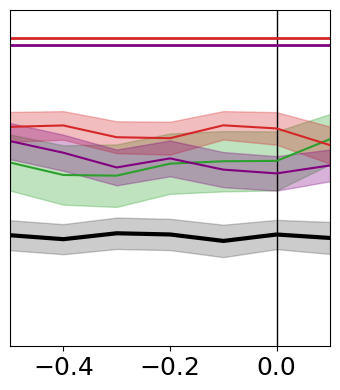

In [8]:
# set path to figures
path_figures = os.path.join(path_root, 'results', 'figures', 'alignment_subspaces' + str(k_start) + 'to' + str(k_end), trial_type, 'figures_02_VAF_pool_features_load2')
if not os.path.isdir(path_figures):
    os.makedirs(path_figures)

time_windows = ['encode', 'maint', 's2']

### apply FDR to all the concatenated p_values

p_values_uncorrected_list_inhibition_vs_surrogate = {}
p_values_uncorrected_list_update_vs_surrogate = {}
p_values_uncorrected_list_control_vs_surrogate = {}

p_values_uncorrected_list_cue_inhibition = {}
p_values_uncorrected_list_cue_update = {}
p_values_uncorrected_list_cue_control = {}

p_values_corrected_list_inhibition_vs_surrogate = {}
p_values_corrected_list_update_vs_surrogate = {}
p_values_corrected_list_control_vs_surrogate = {}

p_values_corrected_list_cue_inhibition = {}
p_values_corrected_list_cue_update = {}
p_values_corrected_list_cue_control = {}

t_values_list_inhibition = {}
t_values_list_update = {}
t_values_list_control = {}

t_values_list_cue_inhibition = {}
t_values_list_cue_update = {}
t_values_list_cue_control = {}

for load_i in [2]:

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # -----------------------------------------
        # Run statistical tests - surrogate
        # -----------------------------------------

        ## inhibition vs surrogate
        p_values = []
        for t in range(data_inhibition.shape[1]):
            t_values, p = ttest_rel(data_inhibition[:, t], surrogate_inhibition[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)

        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_inhibition_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## update vs surrogate
        p_values = []
        for t in range(data_update.shape[1]):
            t_values, p = ttest_rel(data_update[:, t], surrogate_update[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_update_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        ## control vs surrogate
        p_values = []
        for t in range(data_control.shape[1]):
            t_values, p = ttest_rel(data_control[:, t], surrogate_control[:, t])
            if t_values > 0: # only valid for PA
                p_values.append(p)
            else:
                p_values.append(1)


        # pool p-values
        p_values = np.array(p_values)
        p_values = np.nan_to_num(p_values, nan=1.0)

        p_values_uncorrected_list_control_vs_surrogate[time_window + '_' + str(load_i)] = p_values

        # -----------------------------------
        # Run statistical tests - cue effect
        # -----------------------------------

        if time_window == 'encode':

            data_encode_avg_inhibition = data_inhibition.copy()
            data_encode_avg_update = data_update.copy()
            data_encode_avg_control = data_control.copy()

        if time_window == 'maint':

            data_encode_avg_inhibition = np.concatenate((data_encode_avg_inhibition, data_inhibition), axis=1)
            data_encode_avg_update = np.concatenate((data_encode_avg_update, data_update), axis=1)
            data_encode_avg_control = np.concatenate((data_encode_avg_control, data_control), axis=1)

            data_encode_avg_inhibition = np.nanmean(data_encode_avg_inhibition[:,5:18], axis=1)
            data_encode_avg_update = np.nanmean(data_encode_avg_update[:,5:18], axis=1)
            data_encode_avg_control = np.nanmean(data_encode_avg_control[:,5:18], axis=1)

        if time_window != 'encode': # not used here

            ## inhibition

            p_values = []
            t_values = []
            for t in range(data_inhibition.shape[1]):
                t, p = ttest_rel(data_inhibition[:, t], data_encode_avg_inhibition)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_inhibition[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_inhibition[time_window + '_' + str(load_i)] = t_values

            ## update

            p_values = []
            t_values = []
            for t in range(data_update.shape[1]):
                t, p = ttest_rel(data_update[:, t], data_encode_avg_update)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_update[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_update[time_window + '_' + str(load_i)] = t_values

            ## control

            p_values = []
            t_values = []
            for t in range(data_control.shape[1]):
                t, p = ttest_rel(data_control[:, t], data_encode_avg_control)
                p_values.append(p)
                t_values.append(t)

            # pool p-values
            p_values = np.array(p_values)
            p_values = np.nan_to_num(p_values, nan=1.0)

            # pool t-values
            t_values = np.array(t_values)
            t_values = np.nan_to_num(t_values, nan=1.0)

            p_values_uncorrected_list_cue_control[time_window + '_' + str(load_i)] = p_values
            t_values_list_cue_control[time_window + '_' + str(load_i)] = t_values


##### ------------------------------------------------------------------
##### Apply FDR correction - surrogate effect
##### ------------------------------------------------------------------

for load_i in [2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    for time_window in time_windows:

        base_key = f"{time_window}_{load_i}"

        # inhibition
        vals = p_values_uncorrected_list_inhibition_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("inhibition", base_key, len(vals)))

        # update
        vals = p_values_uncorrected_list_update_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("update", base_key, len(vals)))

        # control
        vals = p_values_uncorrected_list_control_vs_surrogate[base_key]
        p_values_uncorrected.extend(vals)
        keys_order.append(("control", base_key, len(vals)))

    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_inhibition_vs_surrogate[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_update_vs_surrogate[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_control_vs_surrogate[key] = corrected_vals


##### ------------------------------------------------------------------
##### Apply FDR correction - cue effect
##### ------------------------------------------------------------------

for load_i in [2]:

    keys_order = []  # track (dict_name, key, n_vals)
    p_values_uncorrected = []

    # ------------------------------------------------------------------
    # vectorize uncorrected p_values
    # ------------------------------------------------------------------

    # vectorize uncorrected p_values
    for time_window in time_windows:

        if time_window != 'encode':

            base_key = f"{time_window}_{load_i}"

            # inhibition
            vals = p_values_uncorrected_list_cue_inhibition[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("inhibition", base_key, len(vals)))

            # update
            vals = p_values_uncorrected_list_cue_update[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("update", base_key, len(vals)))

            # control
            vals = p_values_uncorrected_list_cue_control[base_key]
            p_values_uncorrected.extend(vals)
            keys_order.append(("control", base_key, len(vals)))


    p_values_uncorrected = np.array(p_values_uncorrected)

    # FDR correction
    _, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.025)

    # ------------------------------------------------------------------
    # Put corrected values back into dictionaries
    # ------------------------------------------------------------------
    idx = 0
    for kind, key, n_vals in keys_order:
        corrected_vals = p_values_fdr[idx:idx + n_vals]
        idx += n_vals

        if kind == "inhibition":
            p_values_corrected_list_cue_inhibition[key] = corrected_vals
        elif kind == "update":
            p_values_corrected_list_cue_update[key] = corrected_vals
        elif kind == "control":
            p_values_corrected_list_cue_control[key] = corrected_vals







### plots

for load_i in [2]:

    # find common y-axis limits

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)

        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']


        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])

        # axis limits

        ymax_observed = max((mean_inhibition + std_inhibition).max(), (mean_update + std_update).max(), (mean_control + std_control).max())
        ymin_observed = min((mean_inhibition - std_inhibition).min(), (mean_update - std_update).min(), (mean_control - std_control).min())

        ymax_surrogate = max((mean_inhibition_surrogate + std_inhibition_surrogate).max(), (mean_update_surrogate + std_update_surrogate).max(), (mean_control_surrogate + std_control_surrogate).max())
        ymin_surrogate = min((mean_inhibition_surrogate - std_inhibition_surrogate).min(), (mean_update_surrogate - std_update_surrogate).min(), (mean_control_surrogate - std_control_surrogate).min())

        ymax = max((ymax_observed, ymax_surrogate))
        ymin = min((ymin_observed, ymin_surrogate))

        if time_window == 'encode':

            global_ymin = ymin
            global_ymax = ymax

        else:

            if ymax > global_ymax:
                global_ymax = ymax
            if ymin < global_ymin:
                global_ymin = ymin

    # now, pass the code to do the actual plots

    for time_window in time_windows:

        if time_window == 'encode':

            segments = range(-5,8) # from [-500 -100] ms, to [800 1200] relative to onset of encode period

        elif time_window == 'maint':

            segments = range(-5,20) # from [-500 -100] ms, to [1800 2200] relative to onset of maint period

        elif time_window == 's2':

            segments = range(-5,2) # from [-500 -100] ms, to [200 600] relative to onset of s2 period

        index_of_zero = segments.index(0)


        ## observed

        # load pa
        path_outputs = os.path.join(path_root, 'results', pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', trial_type)

        file_path = os.path.join(path_outputs, 'vaf_' + trial_type + '_' + time_window + '_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_inhibition = np.concatenate((data_1, data_2), axis=0)

        # update
        condition_i = 'update'
        data_1 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        data_2 = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        data_update = np.concatenate((data_1, data_2), axis=0)

        # control
        condition_i = 'control'
        data_control = vaf_dict[condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        ## surrogate

        # load pa
        path_outputs = os.path.join(path_root, 'results', surrogate_pca_aligned_folder, time_window + '_time_resolved', 'allsubjects', 'correct_trials')

        file_path = os.path.join(path_outputs, 'vaf_dict_subspace' + str(k_start) + 'to' + str(k_end) + '.pkl')
        with open(file_path, 'rb') as file:
            vaf_dict = pickle.load(file)

        # inhibition
        condition_i = 'inhibition'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_inhibition = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # update
        condition_i = 'update'
        surrogate_1 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_relevant_' + str(load_i) + 'polygons_nonrelevant']
        surrogate_2 = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_nonrelevant_' + str(load_i) + 'polygons_relevant']
        surrogate_update = np.concatenate((surrogate_1, surrogate_2), axis=0)

        # control
        condition_i = 'control'
        surrogate_control = vaf_dict[time_window + '_' + condition_i + '_' + str(load_i) + 'gratings_' + str(load_i) + 'polygons']

        # ------------------------------------------
        # FDR corrected p-values - surrogate effect
        # ------------------------------------------

        ## inhibition vs update

        p_values_corrected_list = p_values_corrected_list_inhibition_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_inhibition_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## update vs update

        p_values_corrected_list = p_values_corrected_list_update_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_update_vs_surrogate = np.where(p_corrected < 0.025)[0]

        ## control vs update

        p_values_corrected_list = p_values_corrected_list_control_vs_surrogate.copy()

        key = f"{time_window}_{load_i}"
        p_corrected = p_values_corrected_list[key]

        # Find significant timepoints
        significant_timepoints_control_vs_surrogate = np.where(p_corrected < 0.025)[0]


        # ------------------------------------
        # FDR corrected p-values - cue effect
        # ------------------------------------

        if time_window != 'encode':

            ## inhibition 

            p_values_corrected_list = p_values_corrected_list_cue_inhibition.copy()
            t_values_list = t_values_list_cue_inhibition.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_inhibition_cue_positive = []
                significant_timepoints_inhibition_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_inhibition_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_inhibition_cue_negative.append(p_i)

                significant_timepoints_inhibition_cue_positive = np.array(significant_timepoints_inhibition_cue_positive)
                significant_timepoints_inhibition_cue_negative = np.array(significant_timepoints_inhibition_cue_negative)

            else:

                significant_timepoints_inhibition_cue_positive = np.array([])
                significant_timepoints_inhibition_cue_negative = np.array([])

            ## update 

            p_values_corrected_list = p_values_corrected_list_cue_update.copy()
            t_values_list = t_values_list_cue_update.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_update_cue_positive = []
                significant_timepoints_update_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_update_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_update_cue_negative.append(p_i)

                significant_timepoints_update_cue_positive = np.array(significant_timepoints_update_cue_positive)
                significant_timepoints_update_cue_negative = np.array(significant_timepoints_update_cue_negative)

            else:

                significant_timepoints_update_cue_positive = np.array([])
                significant_timepoints_update_cue_negative = np.array([])

            ## control 

            p_values_corrected_list = p_values_corrected_list_cue_control.copy()
            t_values_list = t_values_list_cue_control.copy()

            key = f"{time_window}_{load_i}"
            p_corrected = p_values_corrected_list[key]
            t_values = t_values_list[key]

            # set to one the p-values from timepoints before the cue
            if time_window == 'maint':
                p_corrected[0:4] = 1

            # Find significant timepoints
            significant_timepoints = np.where(p_corrected < 0.025)[0]

            # split positive and negative t-values
            if len(significant_timepoints) > 0:

                significant_timepoints_control_cue_positive = []
                significant_timepoints_control_cue_negative = []

                for p_i in significant_timepoints:
                    if t_values[p_i] > 0:
                        significant_timepoints_control_cue_positive.append(p_i)
                    elif t_values[p_i] < 0:
                        significant_timepoints_control_cue_negative.append(p_i)

                significant_timepoints_control_cue_positive = np.array(significant_timepoints_control_cue_positive)
                significant_timepoints_control_cue_negative = np.array(significant_timepoints_control_cue_negative)

            else:

                significant_timepoints_control_cue_positive = np.array([])
                significant_timepoints_control_cue_negative = np.array([])








        # ---------------------
        # Time axis
        # ---------------------
        time = (np.arange(data_inhibition.shape[1]) - index_of_zero) * 0.1  # sec

        ## Compute means and SEM

        # observed

        mean_inhibition = np.nanmean(data_inhibition, axis=0)
        std_inhibition = np.nanstd(data_inhibition, axis=0) / np.sqrt(data_inhibition.shape[0])

        mean_update = np.nanmean(data_update, axis=0)
        std_update = np.nanstd(data_update, axis=0) / np.sqrt(data_update.shape[0])

        mean_control = np.nanmean(data_control, axis=0)
        std_control = np.nanstd(data_control, axis=0) / np.sqrt(data_control.shape[0])

        # surrogate

        mean_inhibition_surrogate = np.nanmean(surrogate_inhibition, axis=0)
        std_inhibition_surrogate = np.nanstd(surrogate_inhibition, axis=0) / np.sqrt(surrogate_inhibition.shape[0])

        mean_update_surrogate = np.nanmean(surrogate_update, axis=0)
        std_update_surrogate = np.nanstd(surrogate_update, axis=0) / np.sqrt(surrogate_update.shape[0])

        mean_control_surrogate = np.nanmean(surrogate_control, axis=0)
        std_control_surrogate = np.nanstd(surrogate_control, axis=0) / np.sqrt(surrogate_control.shape[0])













        # ---------------------
        # Plot
        # ---------------------

        plt.figure(figsize=(len(segments)/2, 4))

        if time_window == 'encode':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 'maint':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)
            plt.axvline(x=-0.100, color='k', linestyle='-', linewidth=1)
        elif time_window == 's2':
            plt.axvline(x=0, color='k', linestyle='-', linewidth=1)

        if time_window == 'encode':
            plt.xlim(-0.500, 0.700)
        elif time_window == 'maint':
            plt.xlim(-0.500, 1.900)
        elif time_window == 's2':
            plt.xlim(-0.500, 0.100)

        ## surrogate

        # control condition
        plt.plot(time, mean_control_surrogate, label='Control', color='black', linestyle='-', linewidth=3)
        plt.fill_between(time, mean_control_surrogate - std_control_surrogate, mean_control_surrogate + std_control_surrogate, alpha=0.2, color='black')

        ## observed

        # control condition
        plt.plot(time, mean_control, label='Control', color='tab:green')
        plt.fill_between(time, mean_control - std_control, mean_control + std_control, alpha=0.3, color='tab:green')

        # inhibition
        plt.plot(time, mean_inhibition, label='Relevant', color='tab:red')
        plt.fill_between(time, mean_inhibition - std_inhibition, mean_inhibition + std_inhibition, alpha=0.3, color='tab:red')

        # update
        plt.plot(time, mean_update, label='Nonrelevant', color='purple')
        plt.fill_between(time, mean_update - std_update, mean_update + std_update, alpha=0.3, color='purple')



        # y-axis limits
        padding = 0.1 * (global_ymax - global_ymin)
        global_ymin -= padding
        global_ymax += padding
        plt.ylim(global_ymin, global_ymax)




        ### Stats - surrogate effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        # inhibition vs surrogate

        if significant_timepoints_inhibition_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_inhibition_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2)

        # update vs surrogate

        if significant_timepoints_update_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.25)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_update_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2)

        # control vs surrogate

        if significant_timepoints_control_vs_surrogate.size > 0:

            from itertools import groupby
            from operator import itemgetter

            # Get y-limit for top position
            y_line = global_ymax - padding - (padding * 0.5)

            # Group consecutive timepoints
            groups = []
            for k, g in groupby(enumerate(significant_timepoints_control_vs_surrogate), lambda x: x[0] - x[1]):
                group = list(map(itemgetter(1), g))
                groups.append(group)

            # Plot continuous lines over each group
            for group in groups:
                plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:green', linewidth=2)







        ### Stats - cue effect

        ## Significant timepoints (continuous line on top) - separately for each contrast

        if time_window != 'encode':

            # inhibition - positive

            if significant_timepoints_inhibition_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # inhibition - negative

            if significant_timepoints_inhibition_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 1)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_inhibition_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:red', linewidth=2, linestyles=(0, (1, 1)))  

            # update - positive

            if significant_timepoints_update_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.8)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # update - negative

            if significant_timepoints_update_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.6)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_update_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='purple', linewidth=2, linestyles=(0, (1, 1)))  

            # control - positive

            if significant_timepoints_control_cue_positive.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.4)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_positive), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (4, 1)))  # 4 on, 1 off)

            # control - negative

            if significant_timepoints_control_cue_negative.size > 0:

                from itertools import groupby
                from operator import itemgetter

                # Get y-limit for top position
                y_line = global_ymin + padding + (padding * 0.2)

                # Group consecutive timepoints
                groups = []
                for k, g in groupby(enumerate(significant_timepoints_control_cue_negative), lambda x: x[0] - x[1]):
                    group = list(map(itemgetter(1), g))
                    groups.append(group)

                # Plot continuous lines over each group
                for group in groups:
                    plt.hlines(y=y_line, xmin=time[group[0]], xmax=time[group[-1]], color='tab:gray', linewidth=2, linestyles=(0, (1, 1)))  







        # Labels and legend
        if yaxis_labels == 1:
            if time_window == 'encode':
                plt.ylabel('VAF', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(0.1))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])
        elif yaxis_labels == 2:
            if time_window == 'encode' or time_window == 'maint':
                plt.ylabel('VAF', fontsize=20)
                ax = plt.gca()
                ax.yaxis.set_major_locator(MultipleLocator(0.1))
                ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


                ax.tick_params(axis='y', labelsize=18)
            else:
                plt.yticks([])


        if xaxis_labels == False:
            plt.xticks([])
        else:
            if time_window == 'encode':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6], fontsize=18)
            elif time_window == 'maint':
                plt.xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], fontsize=18)
            elif time_window == 's2':
                plt.xticks([-0.4, -0.2, 0], fontsize=18)

        plt.tight_layout()

        # Save figure before showing it
        output_filename = os.path.join(path_figures, 'figure_load' + str(load_i) + '_' + time_window + '.png')
        plt.savefig(output_filename, dpi=300)  # You can change dpi or use .pdf or .svg
        
        plt.show()

